Today, I updated the script for ACs data reading and outlier removal to also calculate the scattering (b) coefficient. In this notebook, I want to analyse the new data.

# 1. Visualization of the absorption, scattering and beam attenuation for all samples

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

labdata_path = "../data/raw/3_laboratory_measurements"

lab_data = pd.read_csv(os.path.join(labdata_path, "sample_s01-s24.csv"))
lab_data["tss_mg_l"] = lab_data["ss_04u_mg_l"] + lab_data["ss_14u_mg_l"]
lab_data_cols_order = ['sample', 'tur_raw_ntu', 'tur_04u_ntu', 'tur_14u_ntu', 'tss_mg_l', 'ss_04u_mg_l',
       'ss_14u_mg_l', 'tp_raw_mg_l', 'tdp_14u_mg_l', 'tdp_04u_mg_l',
       'toc_raw_mg_l', 'doc_14u_mg_l', 'doc_04u_mg_l', 'tn_raw_mg_l',
       'tdn_14u_mg_l', 'tdn_04u_mg_l', ]
lab_data = lab_data[lab_data_cols_order]

metadata = pd.read_csv(os.path.join(labdata_path, "sample_metadata.csv"))
lab_data = metadata.merge(lab_data)


acsdata_path = "../data/processed/"

spectra_A_df = pd.read_csv(os.path.join(acsdata_path,"2026-03-04_acs_a_clean_df.csv"), index_col="index")
sp_cols_A = spectra_A_df.columns[23:]
wav_A = np.array(sp_cols_A.astype("float"))
spectra_A_df = lab_data.merge(spectra_A_df)

spectra_C_df = pd.read_csv(os.path.join(acsdata_path,"2026-03-04_acs_c_clean_df.csv"), index_col="index")
sp_cols_C = spectra_C_df.columns[23:]
wav_C = np.array(sp_cols_C.astype("float"))
spectra_C_df = lab_data.merge(spectra_C_df)

spectra_B_df = pd.read_csv(os.path.join(acsdata_path,"2026-03-04_acs_b_clean_df.csv"), index_col="index")
sp_cols_B = spectra_B_df.columns[23:]
wav_B = np.array(sp_cols_B.astype("float"))
spectra_B_df = lab_data.merge(spectra_B_df)

# Scattering coeff power law fit and how it relates to turbidity

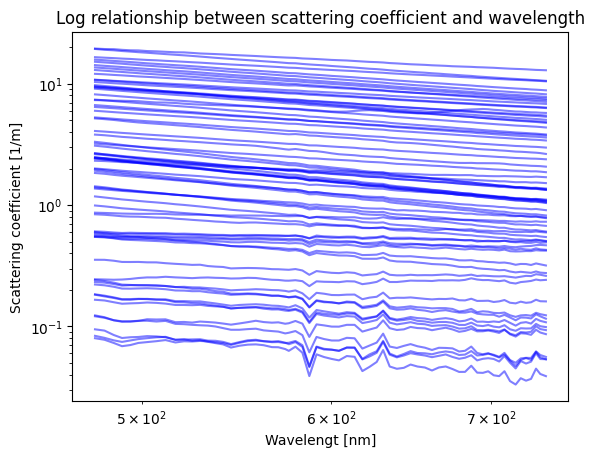

In [9]:
for (i, sample_data) in spectra_B_df.iterrows():
    plt.plot(wav_B, sample_data[sp_cols_B], color="blue", alpha=0.5)

plt.xscale("log"), 
plt.yscale("log")
plt.ylabel("Scattering coefficient [1/m]")
plt.xlabel("Wavelengt [nm]")
plt.title("Log relationship between scattering coefficient and wavelength")
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
C:\Users\pierr\AppData\Local\Temp\ipykernel_28952\3995498790.py:34: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_ylabel('Intercept ($\log a$)')


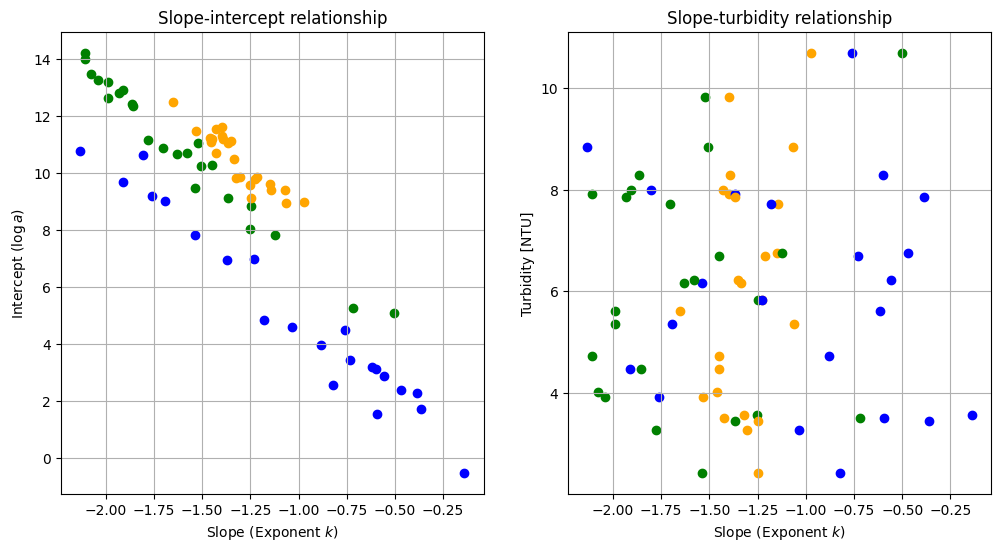

In [10]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))

color_map = {
    "raw": "orange", 
    "04u": "blue", 
    "14u": "green" 
}

for (i, sample_data) in spectra_B_df.iterrows():
    try:
        full_sample_name = sample_data["full_sample_name"]
        
        if "raw" in full_sample_name:
            color = color_map['raw']
            label="raw"
        elif "04u" in full_sample_name:
            color = color_map['04u']
            label="04u"
        elif "14u" in full_sample_name:
            color = color_map['14u']
            label="14u"

        
        y_values = sample_data[sp_cols_B].values.astype(float)
        slope, intercept = np.polyfit(np.log(wav_B), np.log(y_values), 1)
        turbidity = sample_data["tur_raw_ntu"]
        ax[0].scatter(slope, intercept, color=color, label=label)
        ax[1].scatter(slope, turbidity, color=color, label=label)
    except Exception as e:
        print(f"ERROR TYPE: {type(e).__name__}")
        print(f"ERROR MESSAGE: {e}")
    
ax[0].set_xlabel('Slope (Exponent $k$)')
ax[0].set_ylabel('Intercept ($\log a$)')
ax[0].set_title('Slope-intercept relationship')
ax[0].grid(True)
ax[1].set_xlabel('Slope (Exponent $k$)')
ax[1].set_ylabel('Turbidity [NTU]')
ax[1].set_title('Slope-turbidity relationship')
ax[1].grid(True)

plt.show()


The slope-intercept correlation probably an artifact. See:
'''
That high correlation ($p=0.9$) is a classic mathematical artifact known as Sliding-Pivot Correlation. It happens because your intercept is being calculated at a point very far away from your actual data.In a log-log plot of $\ln(\mu_s) = m \cdot \ln(\lambda) + b$, the intercept $b$ is the value at $\ln(\lambda) = 0$ (which is $\lambda = 1$ nm). If your spectrometer measures from 400 nm to 800 nm, your data lives between $\ln(400) \approx 6$ and $\ln(800) \approx 6.7$.When the line "pivots" (the slope $m$ changes) to fit the data in that 400–800 nm window, the "tail" of the line has to swing wildly to hit the y-axis at 1 nm. This creates a forced mathematical link between $m$ and $b$ that has nothing to do with your water chemistry.How to Fix It: "Centering" Your DataTo break this correlation and see if your pollutants actually relate to the physics, you should center your wavelengths around a reference point ($\lambda_0$) within your measurement range.
'''

<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
C:\Users\pierr\AppData\Local\Temp\ipykernel_28952\3234041798.py:61: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel(f'Centered Intercept (log $\mu_s$ at {wav_ref:.0f}nm)')


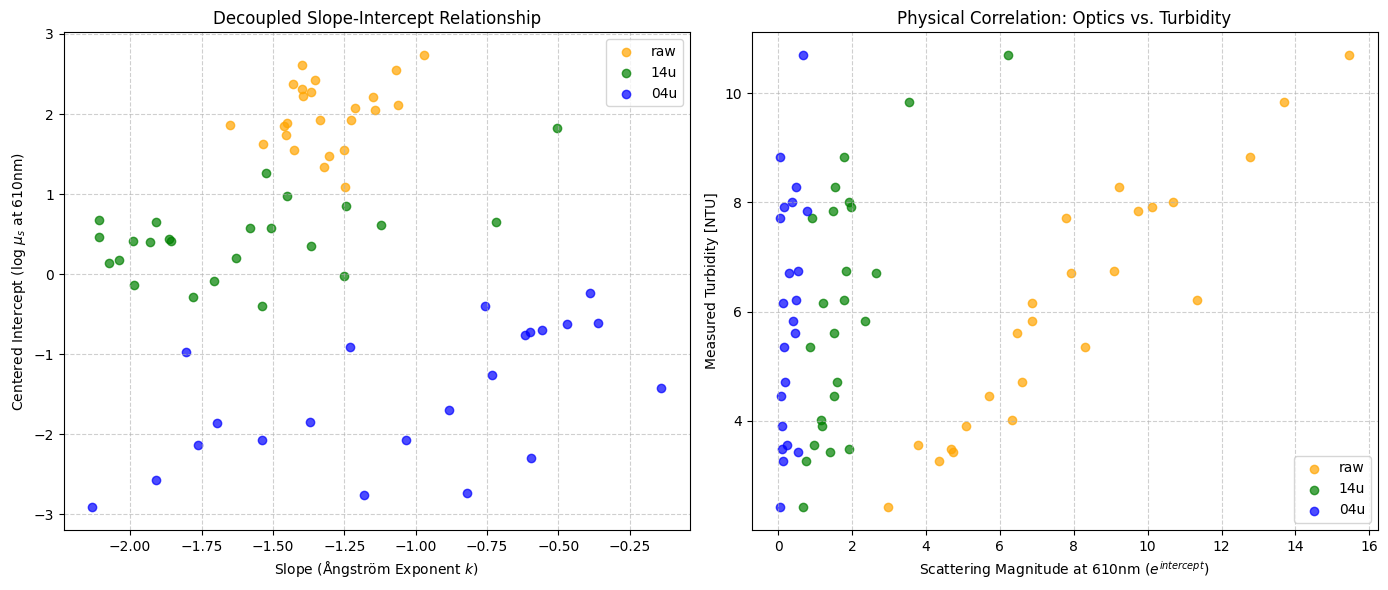

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define your reference wavelength (centering point)
# Using the mean of your wavelength array is the most robust way to decouple m and b.
wav_ref = np.mean(wav_B)

fig, ax = plt.subplots(ncols=2, figsize=(14, 6))

color_map = {
    "raw": "orange", 
    "04u": "blue", 
    "14u": "green" 
}

# Keep track of labels to avoid duplicate legend entries
added_labels = set()

for (i, sample_data) in spectra_B_df.iterrows():
    try:
        full_sample_name = sample_data["full_sample_name"]
        
        # Determine color/label based on sample name
        label = "other"
        for key in color_map:
            if key in full_sample_name:
                label = key
                break
        color = color_map.get(label, "gray")

        # Get the y values (scattering coefficients)
        y_values = sample_data[sp_cols_B].values.astype(float)
        
        # --- THE FIX: Centered Linear Fit ---
        # Instead of np.log(wav_B), we use the log-ratio.
        # This makes the intercept represent the scattering at wav_ref.
        x_centered = np.log(wav_B / wav_ref)
        y_log = np.log(y_values)
        
        slope, centered_intercept = np.polyfit(x_centered, y_log, 1)
        
        # Transform the intercept back to linear space (Scattering Magnitude at wav_ref)
        scat_at_ref = np.exp(centered_intercept)
        turbidity = sample_data["tur_raw_ntu"]

        # Plotting
        display_label = label if label not in added_labels else None
        added_labels.add(label)

        # Plot 1: Slope vs Centered Intercept (Should now show much lower correlation)
        ax[0].scatter(slope, centered_intercept, color=color, label=display_label, alpha=0.7)
        
        # Plot 2: Scattering Magnitude vs Measured Turbidity (Should show high correlation)
        ax[1].scatter(scat_at_ref, turbidity, color=color, label=display_label, alpha=0.7)

    except Exception as e:
        print(f"Error processing row {i}: {e}")

# Formatting Plot 0
ax[0].set_xlabel('Slope (Ångström Exponent $k$)')
ax[0].set_ylabel(f'Centered Intercept (log $\mu_s$ at {wav_ref:.0f}nm)')
ax[0].set_title('Decoupled Slope-Intercept Relationship')
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].legend()

# Formatting Plot 1
ax[1].set_xlabel(f'Scattering Magnitude at {wav_ref:.0f}nm ($e^{{intercept}}$)')
ax[1].set_ylabel('Measured Turbidity [NTU]')
ax[1].set_title('Physical Correlation: Optics vs. Turbidity')
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].legend()

plt.tight_layout()
plt.show()

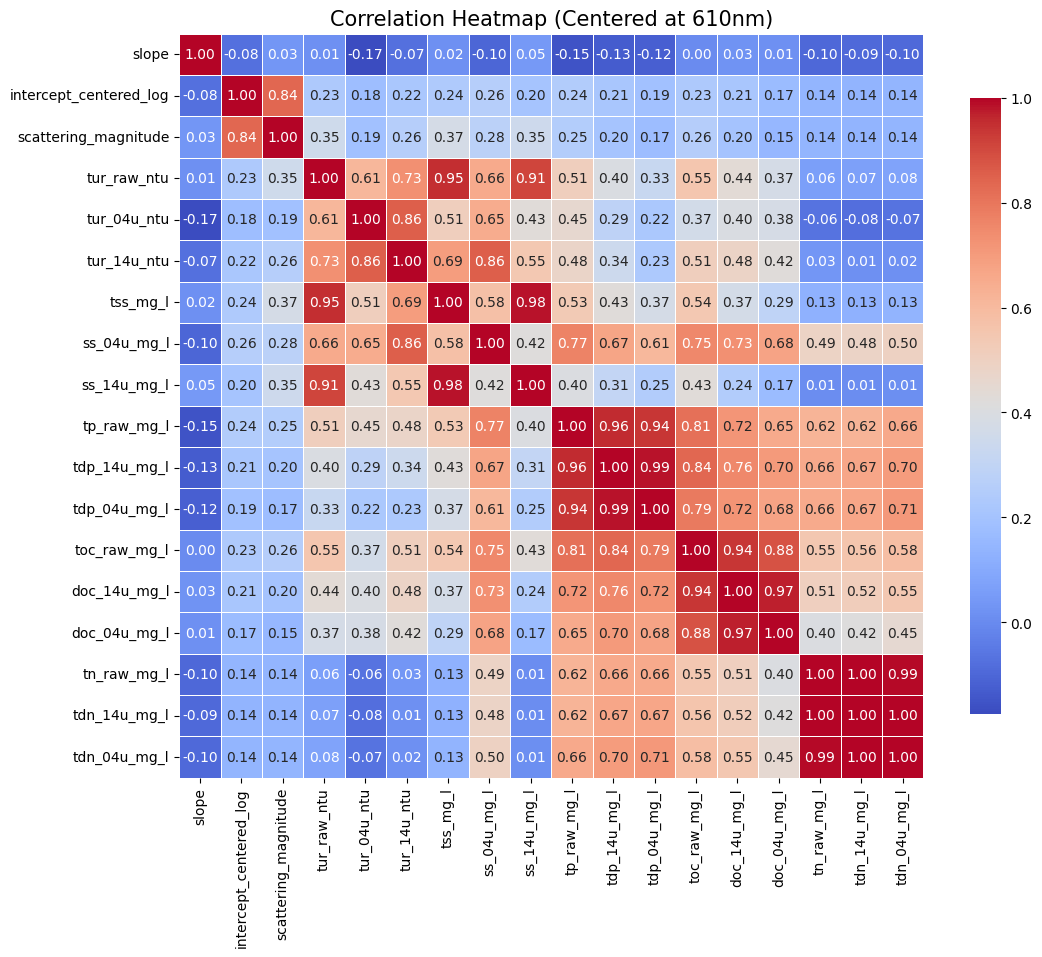

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

slope_intercept_lst = []

# 1. Define a reference wavelength to "center" the data
# This is the key to breaking the 0.9 correlation between slope and intercept.
wav_ref = np.mean(wav_B)

for (i, sample_data) in spectra_B_df.iterrows():
    try:
        full_sample_name = sample_data["full_sample_name"]
        y_values = sample_data[sp_cols_B].values.astype(float)
        
        # Ensure values are positive before logging
        mask = (y_values > 0) & (wav_B > 0)
        
        # --- THE FIX: Centered log-log fit ---
        # We fit: ln(y) = slope * ln(wav / wav_ref) + centered_intercept
        x_centered = np.log(wav_B[mask] / wav_ref)
        y_log = np.log(y_values[mask])
        
        slope, centered_intercept = np.polyfit(x_centered, y_log, 1)
        
        slope_intercept_lst.append({
            "full_sample_name": full_sample_name,
            "slope": slope, 
            "intercept_centered_log": centered_intercept,
            "scattering_magnitude": np.exp(centered_intercept) 
        })

    except Exception as e:
        print(f"ERROR on {full_sample_name}: {type(e).__name__} - {e}")

# Merge the new parameters back into the original dataframe
results_df = pd.DataFrame(slope_intercept_lst)
spectra_merged_df = results_df.merge(spectra_B_df, on="full_sample_name")

# 2. Select columns for Correlation Analysis
# We include the slope, the centered intercept, and the scattering magnitude
new_cols = ["slope", "intercept_centered_log", "scattering_magnitude"]
lab_param_cols = list(spectra_merged_df.columns[10:25]) # Adjust indices if needed
cols_for_corr_analysis = new_cols + lab_param_cols

# 3. Calculate and Plot Heatmap
corr_matrix = spectra_merged_df[cols_for_corr_analysis].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    square=True, 
    linewidths=0.5, 
    cbar_kws={"shrink": .8}
)

plt.title(f'Correlation Heatmap (Centered at {wav_ref:.0f}nm)', fontsize=15)
plt.show()

--- MLR Results ---
Intercept: -1.2698
         Feature  Coefficient
0    tur_raw_ntu     0.066708
1    tur_04u_ntu    -2.653056
2    tur_14u_ntu     0.359454
3       tss_mg_l    -0.026164
4    ss_04u_mg_l    -0.054562
5    ss_14u_mg_l     0.028397
6    tp_raw_mg_l     1.038112
7   tdp_14u_mg_l   -11.254801
8   tdp_04u_mg_l    10.483965
9   toc_raw_mg_l    -0.009682
10  doc_14u_mg_l     0.051991
11  doc_04u_mg_l    -0.011613
12   tn_raw_mg_l     0.142097
13  tdn_14u_mg_l    -0.046583
14  tdn_04u_mg_l    -0.112902
R² Score: 0.205
RMSE: 0.4268


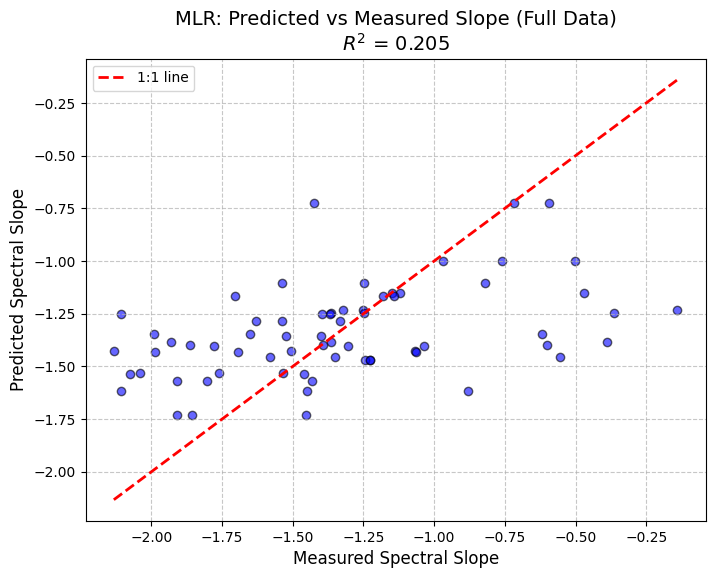

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Features (X) and Target (y)
# Using 'toc' based on your previous dictionary keys
features = list(spectra_B_df.columns[9:24])

# Create a cleaned version of the dataframe
res_df_clean = spectra_B_df.dropna(subset=features+["slope"])

# Re-run the model using the cleaned data
X = res_df_clean[features]
y = res_df_clean['slope']

model = LinearRegression()
model.fit(X, y)

# 2. Initialize and Train the Model on the full dataset
model = LinearRegression()
model.fit(X, y)

# 3. Generate Predictions for the same dataset
y_pred = model.predict(X)

# 4. Calculate Fit Metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

# 5. Display Coefficients and Intercept
print(f"--- MLR Results ---")
print(f"Intercept: {model.intercept_:.4f}")
coeff_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})
print(coeff_df)
print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.4f}")

# 6. Parity Plot: Actual vs. Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.6, edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="1:1 line")

plt.title(f'MLR: Predicted vs Measured Slope (Full Data)\n$R^2$ = {r2:.3f}', fontsize=14)
plt.xlabel('Measured Spectral Slope', fontsize=12)
plt.ylabel('Predicted Spectral Slope', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

--- MLR Results ---
Intercept: -239282.9644
         Feature   Coefficient
0    tur_raw_ntu  5.758837e+04
1    tur_04u_ntu -7.823626e+04
2    tur_14u_ntu -1.027755e+05
3       tss_mg_l -5.197520e+03
4    ss_04u_mg_l  2.609949e+04
5    ss_14u_mg_l -3.129702e+04
6    tp_raw_mg_l  5.906528e+04
7   tdp_14u_mg_l  2.518937e+06
8   tdp_04u_mg_l -1.209321e+06
9   toc_raw_mg_l -5.326300e+03
10  doc_14u_mg_l -2.077445e+02
11  doc_04u_mg_l  2.381549e+03
12   tn_raw_mg_l  7.078047e+04
13  tdn_14u_mg_l  2.730713e+04
14  tdn_04u_mg_l -1.043463e+05
R² Score: 0.222
RMSE: 226367.7426


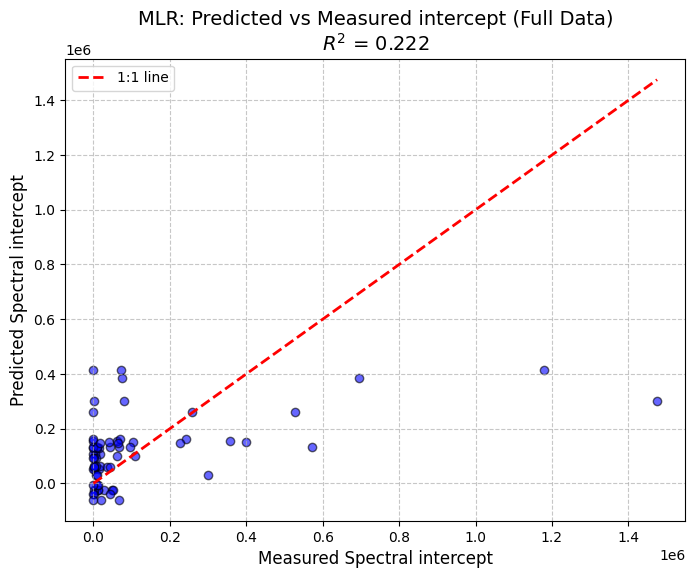

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Features (X) and Target (y)
# Using 'toc' based on your previous dictionary keys
features = list(spectra_B_df.columns[9:24])

# Create a cleaned version of the dataframe
res_df_clean = spectra_B_df.dropna(subset=features+["intercept"])

# Re-run the model using the cleaned data
X = res_df_clean[features]
y = np.exp(res_df_clean['intercept'])

model = LinearRegression()
model.fit(X, y)

# 2. Initialize and Train the Model on the full dataset
model = LinearRegression()
model.fit(X, y)

# 3. Generate Predictions for the same dataset
y_pred = model.predict(X)

# 4. Calculate Fit Metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

# 5. Display Coefficients and Intercept
print(f"--- MLR Results ---")
print(f"Intercept: {model.intercept_:.4f}")
coeff_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})
print(coeff_df)
print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.4f}")

# 6. Parity Plot: Actual vs. Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.6, edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="1:1 line")

plt.title(f'MLR: Predicted vs Measured intercept (Full Data)\n$R^2$ = {r2:.3f}', fontsize=14)
plt.xlabel('Measured Spectral intercept', fontsize=12)
plt.ylabel('Predicted Spectral intercept', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()